# Correlation function for the transverse field Ising model using MPS simulations

## Part a

In [22]:
import a_mps_Gio, b_model_Gio, c_tebd_Gio
import numpy as np
from scipy.linalg import svd
import importlib 
import matplotlib.pyplot as plt
#from tqdm import tqdm

In [63]:
importlib.reload(a_mps_Gio)
importlib.reload(b_model_Gio)
importlib.reload(c_tebd_Gio)

<module 'c_tebd_Gio' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/MPS_simulations/c_tebd_Gio.py'>

In [64]:
sigmay = np.array([[0,-1j],[1j,0]])
sigmax = np.array([[0,1],[1,0]])
sigmaz = np.array([[1., 0.], [0., -1.]])

In [65]:
def construct_intermediate_tensors(psi, psi1, L):
    tensor1 = [np.array([[1]])]
    tensor1.append(np.tensordot(psi.Bs[L-1], psi1.Bs[L-1].conj(), [[1,2],[1,2]])) # vL [i] [vR] , vL* [i*] [vR*] -> vL vL*
    k=1
    #indeces of Bs go from 0 to L-1
    #for j in range(10) goes from 0 to 9 
    #for j in range (9,0,-1) goes from 9 to 1
    for j in range(L-2,0,-1):
        tensor2 = np.tensordot(psi.Bs[j],tensor1[k], [2,0]) # vL i [vR] ,[vL] vL* -> vL i vL*
        tensor1.append(np.tensordot(tensor2, psi1.Bs[j].conj(), [[1,2],[1,2]])) # vL [i] [vL*], vL* [i*] [vR*] ->  vL vL*
        k+=1
    
    return tensor1


def correlation_allsites(psi, psi1, X, L):

    tensor1 = construct_intermediate_tensors(psi,psi1,L)

    corr_list = []

    tensorA = np.tensordot(psi.Bs[0], psi1.Bs[0].conj(),[[0,1],[0,1]]) # [vL] [i] vR , [vL*] [i*] vR* -> vR vR*
    tensorB = np.tensordot(psi.Bs[0], X, [1,1]) # vL [i] vR , i [i*] -> vL vR i
    tensorC = np.tensordot(tensorB,psi1.Bs[0].conj(), [[0,2],[0,1]]) # [vL] vR [i], [vL*] [i*] vR* -> vR vR*
    corr_list.append(np.tensordot(tensorC,tensor1[L-1], [[0,1],[0,1]])) # [vR] [vR*], [vL] [vL*]

    for j in range(1,L):
        tensorB = np.tensordot(psi.Bs[j], X, [1,1]) # vL [i] vR , i [i*] -> vL vR i
        tensorbeforeC = np.tensordot(tensorA, tensorB, [0,0]) # [vR] vR*, [vL] vR i -> vR* vR i
        tensorC = np.tensordot(tensorbeforeC,psi1.Bs[j].conj(), [[0,2],[0,1]]) # [vR*] vR [i], [vL*] [i*] vR* -> vR vR*
        #print(tensorC.shape)
        #print(tensor1[L-j-2].shape) #- mettili se c'è sum mismatch prima di un certo tensorproduct
        corr_list.append(np.tensordot(tensorC,tensor1[L-j-1], [[0,1],[0,1]])) # [vR] [vR*], [vL] [vL*]
        #tensorintermediate = np.tensordot(psi1.Bs[j], psi.Bs[j].conj(),[1,1]) # vL [i] vR , vL* [i*] vR* -> vL vR vL* vR*
        #tensorloop = np.tensordot(tensorA, tensorintermediate, [[0,1],[0,2]]) # [vR] [vR*], [vL] vR [vL*] vR* -> vR vR*
        tensorintermediate = np.tensordot(tensorA, psi.Bs[j], [0,0]) # [vR] vR*, [vL] i vR -> vR* i vR
        tensorloop = np.tensordot(tensorintermediate, psi1.Bs[j].conj(), [[0,1],[0,1]]) # [vR*] [i] vR, [vL*] [i*] vR* -> vR vR*
        tensorA = tensorloop    

    return corr_list

In [ ]:
import pickle
import os

def correlation_Ctj(L, J, g, X, Y, n, dt, k = 0.5, h = 0, chi_max = 200, 
                    save_results = False, savedir = "simulations", ops_name = "sigmay"):
    if g>J: #paramagnetic case
        E0, psi, model = c_tebd_Gio.example_TEBD_gs_finite(L,J,g,h,k)
    else: #ferromagnetic case -> have to find unique gs
        E0, psi, _ = c_tebd_Gio.example_TEBD_gs_finite(L,J,g,h=10**-2.5,k=k)
        model = b_model_Gio.TFIModel(L,J=J,g=g,h=h,k=k)

        #check magnetization
        sigmax = np.array([[0,1],[1,0]])
        x_value = correlation_allsites(psi, psi, sigmax, L)
        print(np.mean(x_value))
        if np.mean(x_value) > 0:
            print("Ground state is the one with positive magnetization")
        else:
            print("Ground state is the one with negative magnetization")

    psi1 = psi.copy() #take a copy of psi which is ground state
    S = []
    i = L//2 # i= L//2 index of Y
    tensor1 = np.tensordot(psi.Bs[i], Y, [1,1]) # vL [i] vR, i [i*] -> vL vR i
    psi.Bs[i] = tensor1.transpose([0,2,1])
    
    U_bond = c_tebd_Gio.calc_U_bonds_real(model, dt)
    result = []
    N=2**n

    for r in range(N):
        exp_factor = np.exp(1j*E0*r*dt)
        
        if r != 0:
            c_tebd_Gio.run_TEBD(psi, U_bond, N_steps=1, chi_max=chi_max, eps=1.e-10) #found new psi by applying e^-iHdt
        S.append(psi.entanglement_entropy())

        corr_list = correlation_allsites(psi, psi1, X, L)

        result.append(np.array(corr_list) * exp_factor)

    if save_results:
        if g>J:
            phase = "para"
        else:
            phase = "ferro"
        
        subfold = (f"_L{L}" 
            + f"_{ops_name}"
            + f"_n{n}"
            + f"_dt{dt}"
            + f"_g{g}"
            +f"_J{J}"
            +f"_k{k}"
            +f"_h{h}"
            +f"_chi{chi_max}"
            +".pkl")
        
        filename_s = "S.pkl"

        filename_corr = "Corr.pkl"

        fpath_s = os.path.join(savedir, phase, subfold, filename_s)
        fpath_corr = os.path.join(savedir, phase, subfold, filename_corr)

        os.makedirs(os.path.dirname(fpath_s), exist_ok=True)
        os.makedirs(os.path.dirname(fpath_corr), exist_ok=True)

        with open(fpath_s, "wb") as f:
            pickle.dump(S, f)

        with open(fpath_corr, "wb") as f:
            pickle.dump(result, f)

    return S, result

In [67]:
def correlation_Ctj_old(L, J, g, X, Y, T, dt, h = 0): #model - Hamiltonian, psi - class of wave function, T - last time step 
    E0, psi, model = c_tebd_Gio.example_TEBD_gs_finite(L,J,g, h)
    psi1 = psi.copy() #take a copy of psi which is ground state
    S = []
    i = L//2 # i= L//2 index of Y
    tensor1 = np.tensordot(psi.Bs[i], Y, [1,1]) # vL [i] vR, i [i*] -> vL vR i
    psi.Bs[i] = tensor1.transpose([0,2,1])
    U_bond = c_tebd_Gio.calc_U_bonds_real(model, dt)
    result = []
    TT = int(T//dt)
    for r in range(TT):

        exp_factor = np.exp(1j*E0*r*dt)
        if r != 0:
            c_tebd_Gio.run_TEBD(psi, U_bond, N_steps=1, chi_max=100, eps=1.e-10) #found new psi by applying e^-iHdt
        S.append(psi.entanglement_entropy())
        tensor1 = [np.array([[1]])]
        tensor1.append(np.tensordot(psi.Bs[L-1], psi1.Bs[L-1].conj(), [[1,2],[1,2]])) # vL [i] [vR] , vL* [i*] [vR*] -> vL vL*
        k=1
        #indeces of Bs go from 0 to L-1
        #for j in range(10) goes from 0 to 9 
        #for j in range (9,0,-1) goes from 9 to 1
        for j in range(L-2,0,-1):
            tensor2 = np.tensordot(psi.Bs[j],tensor1[k], [2,0]) # vL i [vR] ,[vL] vL* -> vL i vL*
            tensor1.append(np.tensordot(tensor2, psi1.Bs[j].conj(), [[1,2],[1,2]])) # vL [i] [vL*], vL* [i*] [vR*] ->  vL vL*
            #tensor2 = np.tensordot(psi1.Bs[j], psi.Bs[j].conj(), [1,1])  vL [i] vR , vL* [i*] vR* -> vL vR vL* vR*
            #tensor1.append(np.tensordot(tensor2,tensor1[k],[[1,3],[0,1]])) # vL [vR] vL* [vR*], [vL] [vL*] -> vL vL*
            k+=1
        # print(len(tensor1)) 
        #k = L-1
        result.append([])
        tensorA = np.tensordot(psi.Bs[0], psi1.Bs[0].conj(),[[0,1],[0,1]]) # [vL] [i] vR , [vL*] [i*] vR* -> vR vR*
        tensorB = np.tensordot(psi.Bs[0], X, [1,1]) # vL [i] vR , i [i*] -> vL vR i
        tensorC = np.tensordot(tensorB,psi1.Bs[0].conj(), [[0,2],[0,1]]) # [vL] vR [i], [vL*] [i*] vR* -> vR vR*
        result[r].append(np.tensordot(tensorC,tensor1[L-1], [[0,1],[0,1]])) # [vR] [vR*], [vL] [vL*]

        for j in range(1,L):
            tensorB = np.tensordot(psi.Bs[j], X, [1,1]) # vL [i] vR , i [i*] -> vL vR i
            tensorbeforeC = np.tensordot(tensorA, tensorB, [0,0]) # [vR] vR*, [vL] vR i -> vR* vR i
            tensorC = np.tensordot(tensorbeforeC,psi1.Bs[j].conj(), [[0,2],[0,1]]) # [vR*] vR [i], [vL*] [i*] vR* -> vR vR*
            #print(tensorC.shape)
            #print(tensor1[L-j-2].shape) #- mettili se c'è sum mismatch prima di un certo tensorproduct
            result[r].append(np.tensordot(tensorC,tensor1[L-j-1], [[0,1],[0,1]])) # [vR] [vR*], [vL] [vL*]
            #tensorintermediate = np.tensordot(psi1.Bs[j], psi.Bs[j].conj(),[1,1]) # vL [i] vR , vL* [i*] vR* -> vL vR vL* vR*
            #tensorloop = np.tensordot(tensorA, tensorintermediate, [[0,1],[0,2]]) # [vR] [vR*], [vL] vR [vL*] vR* -> vR vR*
            tensorintermediate = np.tensordot(tensorA, psi.Bs[j], [0,0]) # [vR] vR*, [vL] i vR -> vR* i vR
            tensorloop = np.tensordot(tensorintermediate, psi1.Bs[j].conj(), [[0,1],[0,1]]) # [vR*] [i] vR, [vL*] [i*] vR* -> vR vR*
            tensorA = tensorloop

        result[r] = np.array(result[r])* exp_factor

    return S, result

## Simulations

### Ferromagnetic

In [235]:
L = 11; J = 1.; g = 0.1; X = sigmay; Y = sigmay; n = 12; dt = 0.01; k = 0.1; h = 0; chi_max = 200
N = 2**n

In [236]:
S_ferro, Corr_ferro = correlation_Ctj(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max)

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -10.0988021739201
dt = 0.01000: E = -10.1023720847808
dt = 0.00100: E = -10.1027482619592
dt = 0.00010: E = -10.1027860674923
dt = 0.00001: E = -10.1027898482435
final bond dimensions:  [2, 4, 8, 16, 20, 20, 16, 8, 4, 2]
0.9873132683964457
Ground state is the one with positive magnetization


In [183]:
# S_ferro_old, Corr_ferro_old = correlation_Ctj_old(L = L, J = J, g = g, X = X, Y = Y, T = N*dt, dt = dt, h = h)

Plot of Correlation Function

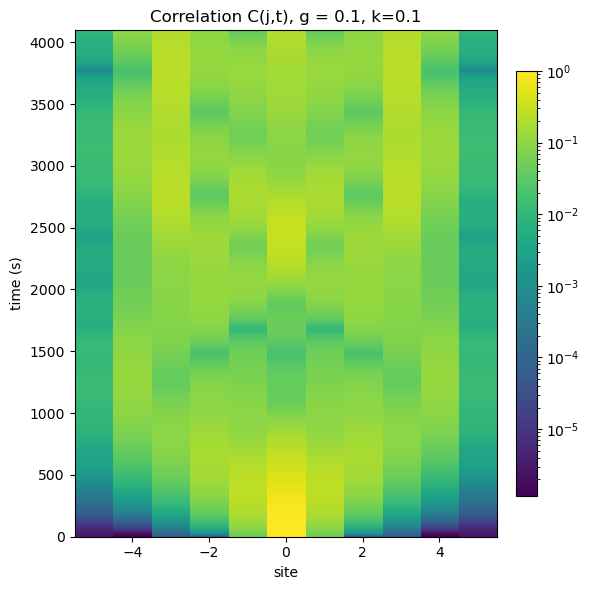

In [216]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize = (6,6))
data = np.abs(Corr_ferro)
im = ax.imshow(data, norm=LogNorm(vmin=data.min(), vmax=data.max()),
                       aspect='auto', interpolation='none', origin='lower',
                       extent=[-(L//2)-0.5, L//2+0.5, 0, N])
# im = ax.imshow(data, aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N])
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title(f'Correlation C(j,t), g = {g}, k={k}')
ax.set(xlabel = 'site', ylabel = 'time (s)')
# ax.set(ylim=[0,1200])
# ax.plot(np.linspace(0,L//2+0.5,100), np.linspace(0,850,100))
# ax.plot(np.linspace(0,-L//2+0.5,100), np.linspace(0,850,100))
plt.tight_layout()

-6 5


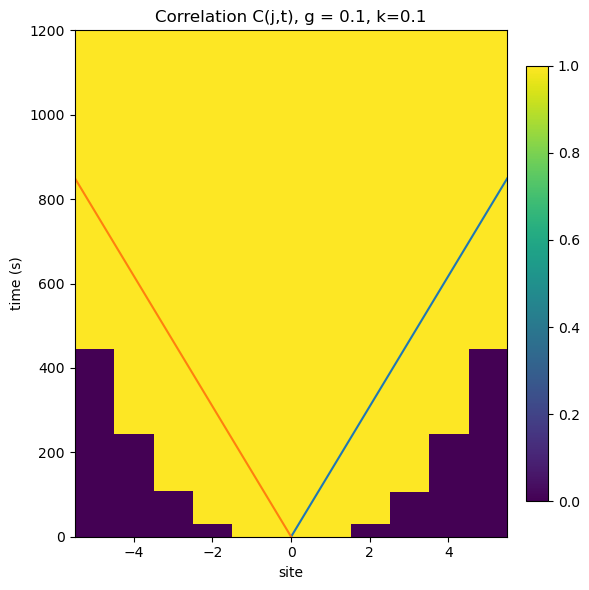

In [238]:
fig, ax = plt.subplots(figsize = (6,6))
new_corr = np.where(np.abs(Corr_ferro) > 10**-3, 1, 0)
# im = ax.imshow(np.abs(Corr_ferro), aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5,0,N])
im = ax.imshow(new_corr, aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N])
print(-L//2, L//2)
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title(f'Correlation C(j,t), g = {g}, k={k}')
ax.set(xlabel = 'site', ylabel = 'time (s)')
ax.set(ylim=[0,1200])
ax.plot(np.linspace(0,L//2+0.5,100), np.linspace(0,850,100))
ax.plot(np.linspace(0,-L//2+0.5,100), np.linspace(0,850,100))
plt.tight_layout()

In [167]:
print(new_corr.shape)
corr = new_corr[:,L//2+1:]
x = np.arange(0,L//2-1,1)
y = []
for i in range(L//2-1):
    y.append(np.where(corr[:,i])[0][0])


(4096, 11)


In [168]:
print(L//2)

5


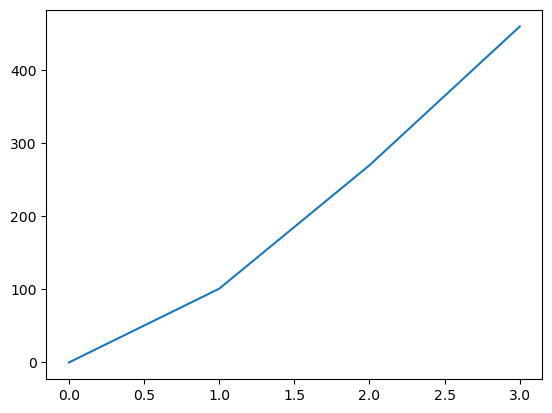

In [177]:
plt.plot(x,y)

coefficients:  154.89999996220192 -24.59999991180451


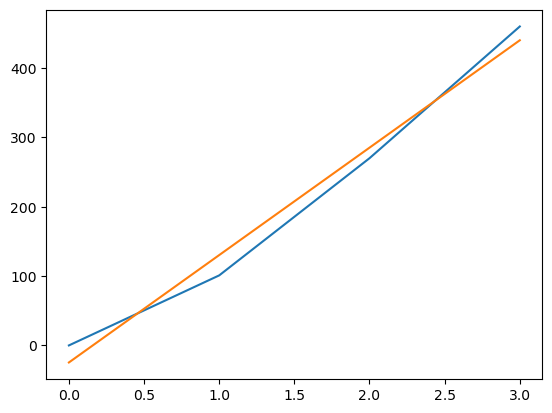

In [178]:
from scipy.optimize import curve_fit

def test(x,a,b):
    return a*x+b

param, param_cov = curve_fit(test, x, y)

ans = test(x,param[0],param[1])

plt.plot(x,y)
plt.plot(x,ans)

print("coefficients: ", param[0], param[1])

In [163]:
coeff = 4100/25
print(coeff)

164.0


In [162]:
2**12/5
850*5


163.84

-6 5


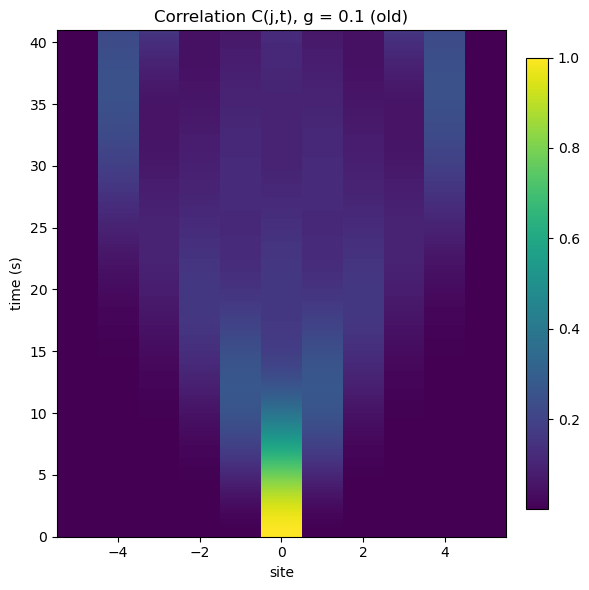

In [75]:
fig, ax = plt.subplots(figsize = (6,6))

im = ax.imshow(np.abs(Corr_ferro_old), aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N*dt])
print(-L//2, L//2)
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title(f'Correlation C(j,t), g = {g} (old)')
ax.set(xlabel = 'site', ylabel = 'time (s)')

plt.tight_layout()

In [207]:
from matplotlib.colors import LogNorm

def simulation_ferro(L, J, g, X, Y, n, dt, k = 0, h = 0, chi_max = 200, log=True, ylim=None, ax=None):
    _, Corr_ferro = correlation_Ctj(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max)
    # ensure N is defined locally and fig is always available
    N = 2**n
    if ax is None:
        fig, ax = plt.subplots(figsize = (6,6))
        created_fig = True
    else:
        # get the Figure object from the provided Axes
        fig = ax.figure
        created_fig = False

    if log:
        # magnitude, avoid zeros
        data = np.abs(Corr_ferro)
        eps = 1e-15
        data = np.where(data > eps, data, eps)
        im = ax.imshow(data, norm=LogNorm(vmin=data.min(), vmax=data.max()),
                       aspect='auto', interpolation='none', origin='lower',
                       extent=[-(L//2)-0.5, L//2+0.5, 0, N])
    else:
        im = ax.imshow(np.abs(Corr_ferro), aspect='auto', interpolation='none', origin='lower',
                       extent=[-(L//2)-0.5, L//2+0.5, 0, N])

    fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
    ax.set_title(f'Correlation C(j,t), g = {g}, k = {k}')
    ax.set(xlabel = 'site', ylabel = 'time (s)')
    if ylim is not None:
        ax.set(ylim=ylim)
    plt.tight_layout()
    if created_fig:
        plt.show()
# ...existing code...

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.05, h = 0.0031622776601683794, k = 0.000
dt = 0.10000: E = -10.0428270370252
dt = 0.01000: E = -10.0428614937664
dt = 0.00100: E = -10.0428637885426
dt = 0.00010: E = -10.0428640092799
dt = 0.00001: E = -10.0428640312684
final bond dimensions:  [2, 4, 6, 6, 6, 6, 6, 6, 4, 2]
0.9978751564494599
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.000
dt = 0.10000: E = -10.0671703734477
dt = 0.01000: E = -10.0672072633414
dt = 0.00100: E = -10.0672097881570
dt = 0.00010: E = -10.0672100318486
dt = 0.00001: E = -10.0672100561316
final bond dimensions:  [2, 4, 7, 8, 8, 8, 8, 7, 4, 2]
0.9941295787546974
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.20, h = 0.0031622776601683794, k = 0.000
dt = 0.10000: E = -10.1647786843919
dt = 0.01000: E = -10.1648505581009
dt = 0.00100: E = -10.

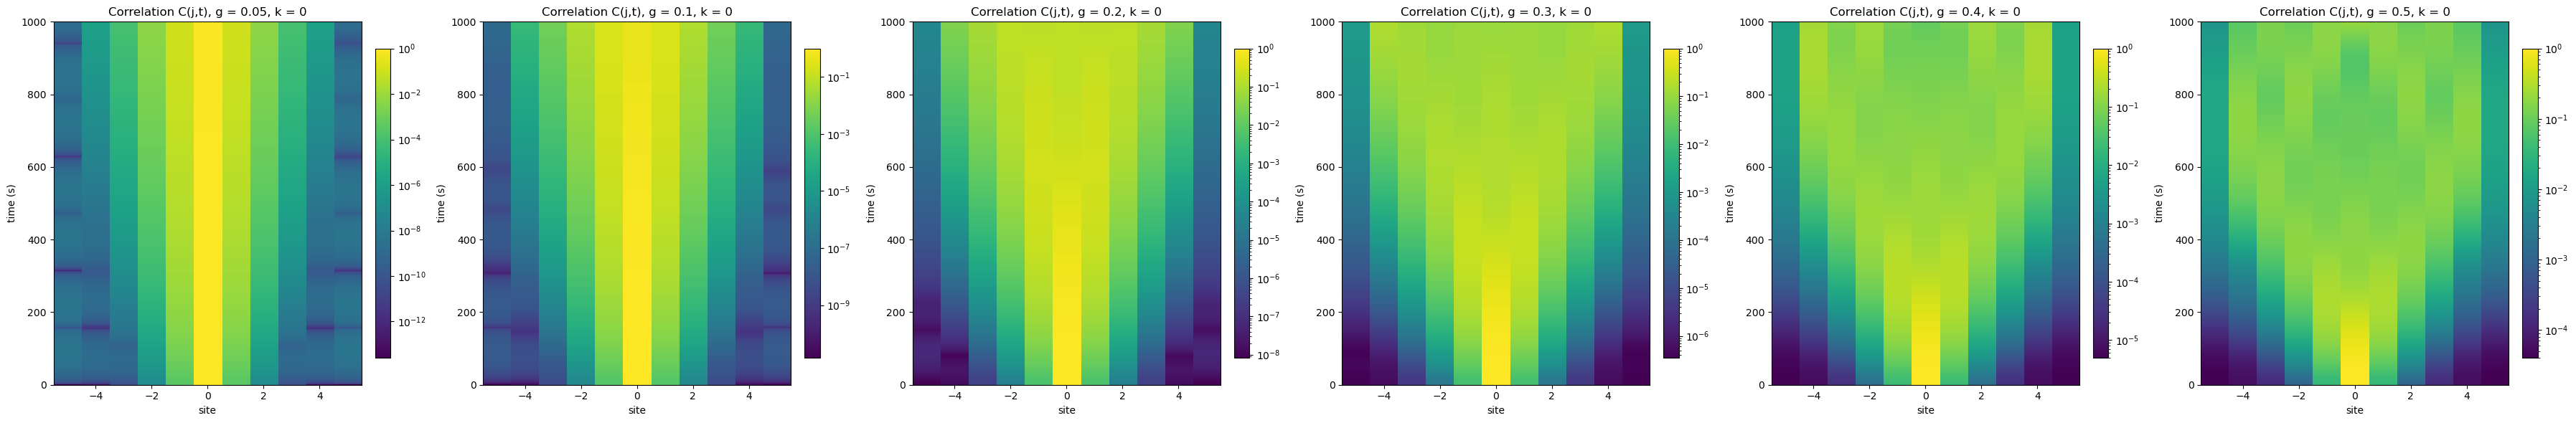

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.05, h = 0.0031622776601683794, k = 0.050
dt = 0.10000: E = -10.0499983102151
dt = 0.01000: E = -10.0508923725416
dt = 0.00100: E = -10.0509858258081
dt = 0.00010: E = -10.0509952114651
dt = 0.00001: E = -10.0509961500158
final bond dimensions:  [2, 4, 8, 14, 16, 16, 14, 8, 4, 2]
0.9964353983059259
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.050
dt = 0.10000: E = -10.0762603770784
dt = 0.01000: E = -10.0772241206154
dt = 0.00100: E = -10.0773246007420
dt = 0.00010: E = -10.0773346907362
dt = 0.00001: E = -10.0773356997176
final bond dimensions:  [2, 4, 8, 14, 17, 17, 14, 8, 4, 2]
0.992065635946065
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.20, h = 0.0031622776601683794, k = 0.050
dt = 0.10000: E = -10.1816136051711
dt = 0.01000: E = -10.1828836114648
dt = 0.00100: E

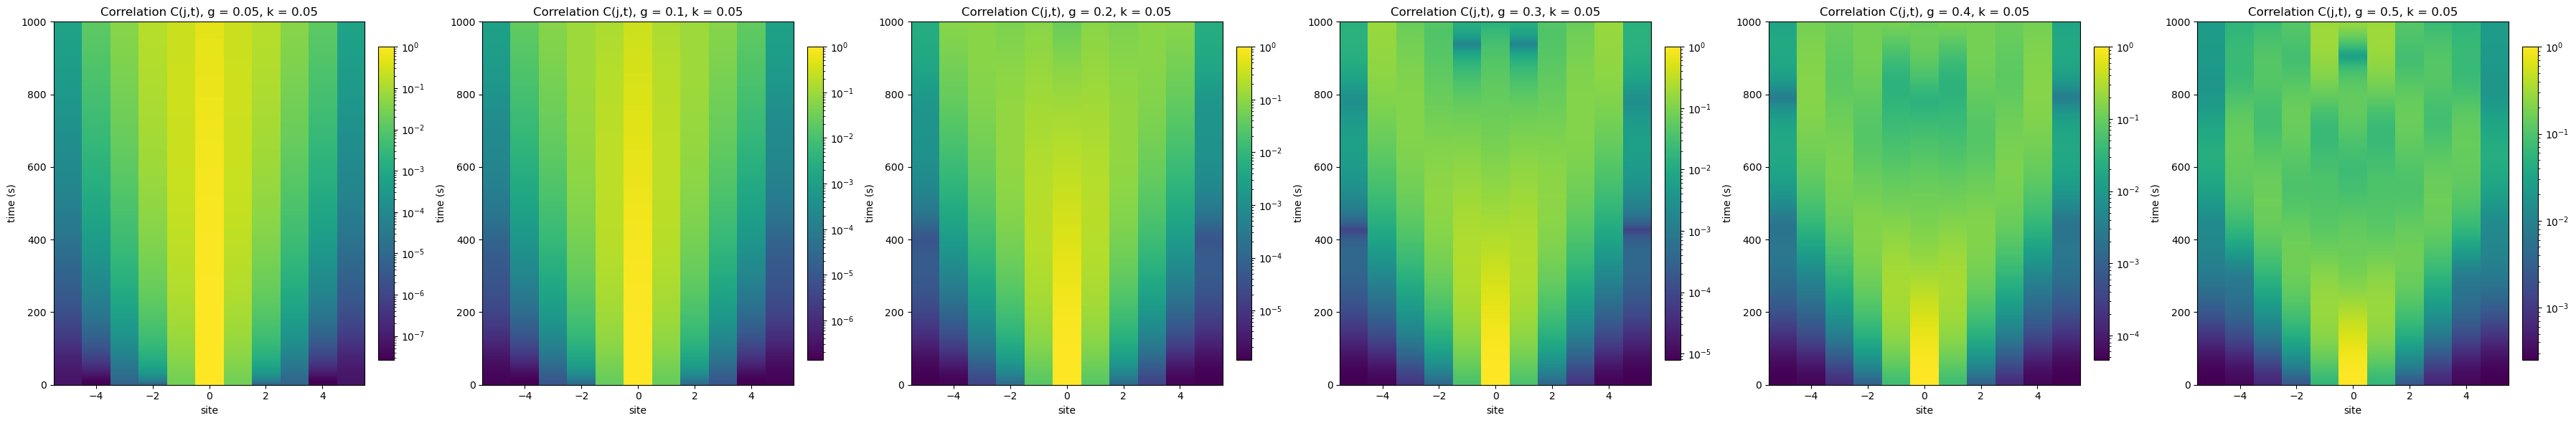

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.05, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -10.0703459349472
dt = 0.01000: E = -10.0737720722140
dt = 0.00100: E = -10.0741340539754
dt = 0.00010: E = -10.0741704386094
dt = 0.00001: E = -10.0741740772789
final bond dimensions:  [2, 4, 8, 16, 20, 20, 16, 8, 4, 2]
0.9924700529499856
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -10.0988021739201
dt = 0.01000: E = -10.1023720847808
dt = 0.00100: E = -10.1027482619592
dt = 0.00010: E = -10.1027860674923
dt = 0.00001: E = -10.1027898482435
final bond dimensions:  [2, 4, 8, 16, 20, 20, 16, 8, 4, 2]
0.9873132683964457
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.20, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -10.2130246330385
dt = 0.01000: E = -10.2172031397228
dt = 0.00100: 

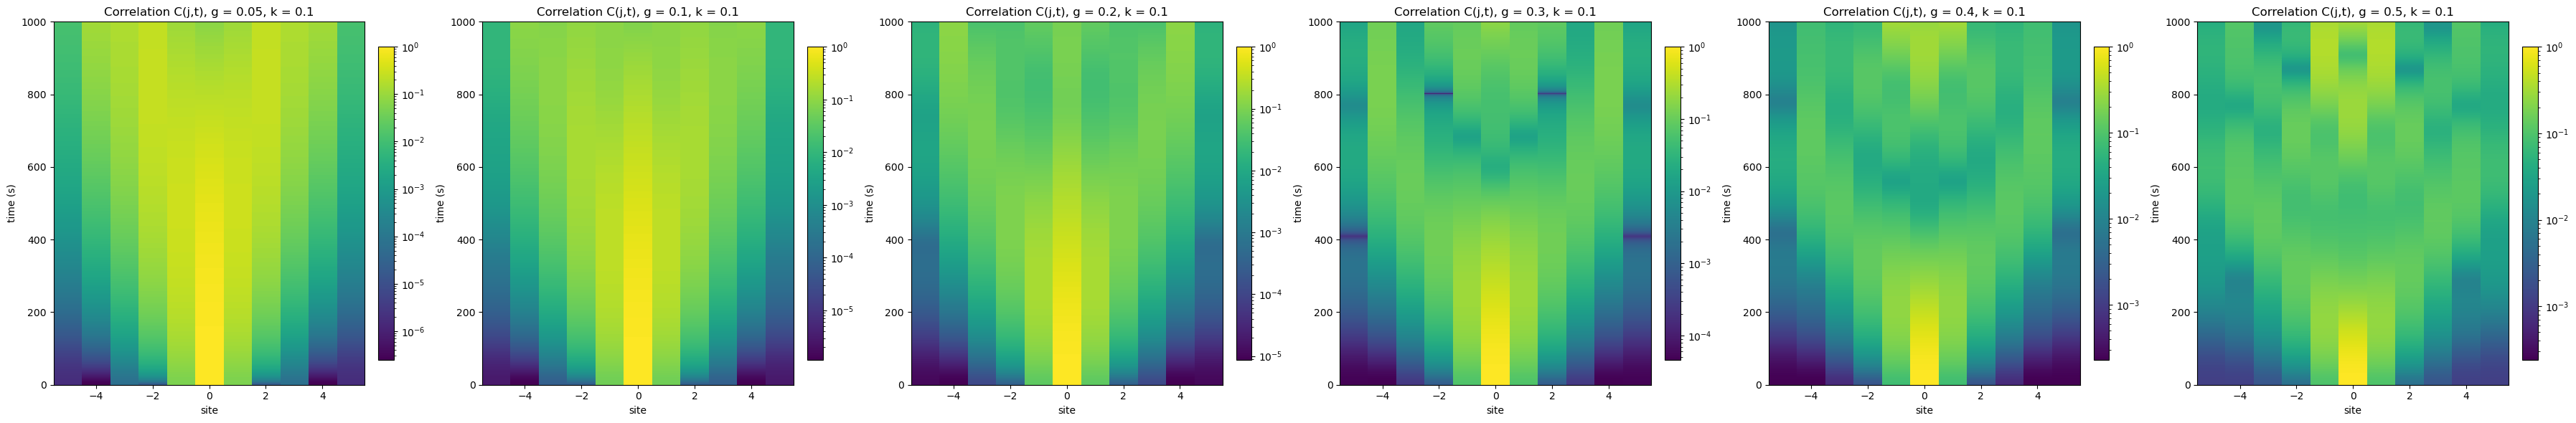

In [209]:
g_list = [0.05,0.1,0.2,0.3,0.4,0.5]
k_list = [0, 0.05, 0.1]
L = 11; J = 1.; X = sigmay; Y = sigmay; n = 12; dt = 0.01; h = 0; chi_max = 200
N = 2**n

for k in k_list:
    fig, ax = plt.subplots(nrows = 1, ncols = len(g_list), figsize = (6*len(g_list),6))
    for i, g in enumerate(g_list):
        simulation_ferro(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max, log=True, ylim=[0,1000], ax=ax[i])
    plt.show()


### Paramagnetic

In [58]:
S_para, Corr_para = correlation_Ctj(L = L, J = J, g = 2, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max)

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=2.00, h = 0, k = 0.100
dt = 0.10000: E = -24.1081504596669
dt = 0.01000: E = -24.1984851464065
dt = 0.00100: E = -24.2073282130231
dt = 0.00010: E = -24.2082081676558
dt = 0.00001: E = -24.2082962333497
final bond dimensions:  [2, 4, 8, 14, 14, 14, 14, 8, 4, 2]


Plot of Correlation Function

-6 5


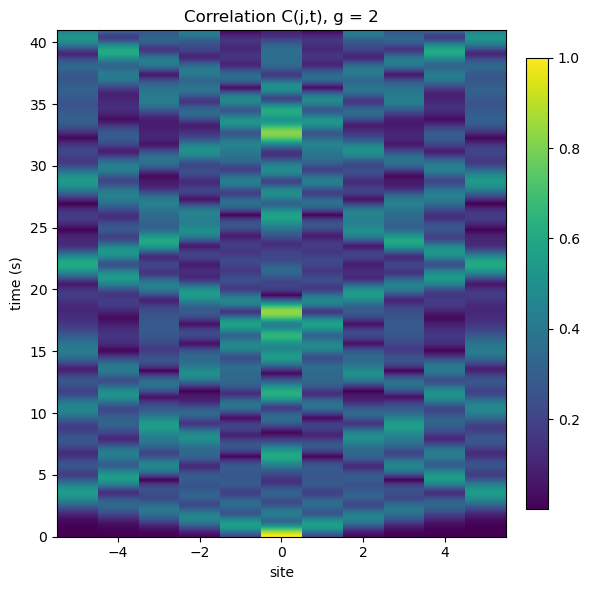

In [59]:
fig, ax = plt.subplots(figsize = (6,6))

im = ax.imshow(np.abs(Corr_para), aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N*dt])
print(-L//2, L//2)
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title('Correlation C(j,t), g = 2')
ax.set(xlabel = 'site', ylabel = 'time (s)')

plt.tight_layout()

## Part b 

- Write another function that performs a Fourier transformation in space and time to obtain the dynamic structure factor $S(k, \omega)$:

$$
S(k, \omega) = \sum^{L−1}_{j=0} \sum^N_{t_n = 0}e^{i\omega \delta t \cdot t_n − i k \cdot j} C(\Delta t \cdot t_n, j) · G(tn)
$$


- Remember to multiply the signal with a Gaussian window function G(tn) in order to avoid Gibbs oscillations from the Fourier transform of the finite time data (cf. equation (7)).

In [6]:
import FourierTransform as FT
importlib.reload(FT)

<module 'FourierTransform' from '/Users/giovanniconcheri/Library/CloudStorage/OneDrive-TUM/Magistrale/FoPra/Fopra32/Fopra32/FourierTransform.py'>

Now we have found C(t,j)= C_t,j which is a matrix (list) with each row corresponding to a specific time step where correlation function is evaluated for each site j (for sigmay_j) 

In [8]:
Corr_ferro = np.array(Corr_ferro)
Corr_para = np.array(Corr_para)

In [9]:
Swk_ferro, momenta_ferro, freqs_ferro = FT.get_Swk(Corr_ferro, L = 50, dt = 0.01)
Swk_para, momenta_para, freqs_para = FT.get_Swk(Corr_para, L = 80, dt = 0.01)


Compute Fourier transform
finished
Compute Fourier transform
finished


# Part c: 
Obtain S(k,w) and plot it

1999
(51,)
51


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


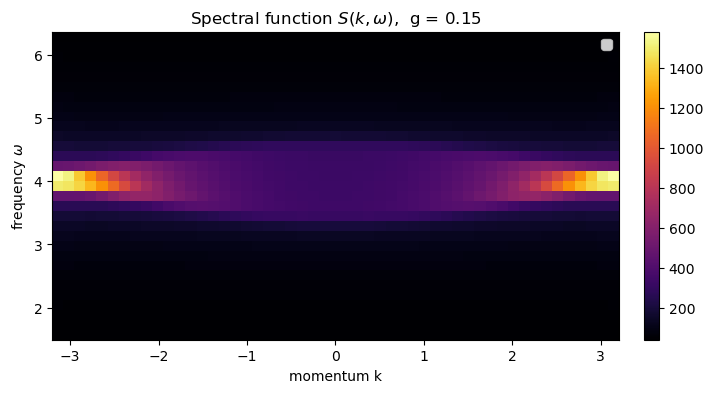

In [32]:
FT.plot_Swk(Swk_ferro, momenta_ferro, freqs_ferro, title = r'Spectral function $S(k, \omega)$,  g = 0.15', offset=10, interval=30)

749
(81,)
81


/Users/giovanniconcheri/Library/CloudStorage/OneDrive-TUM/Magistrale/FoPra/Fopra32/Fopra32/FourierTransform.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


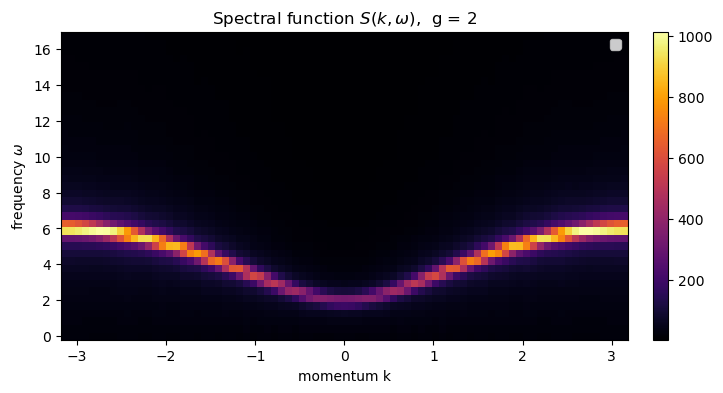

In [10]:
FT.plot_Swk(Swk_para, momenta_para, freqs_para, title = r'Spectral function $S(k, \omega)$,  g = 2', offset=0, interval=40)

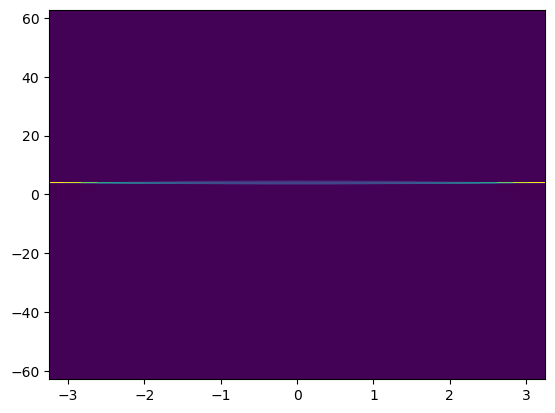

In [33]:
plt.figure()
plt.pcolormesh(momenta, freqs, np.real(Swk))

### $S(k,\omega)$ at g= 0.2 and h = 0.1

In [14]:
S_new, Corr_new = correlation_Ctj(L = 60, J = 1.,g = 0.2, X = sigmay, Y = sigmay, T = 80, dt = 0.001, h = 0.1)

finite TEBD, (imaginary time evolution)
L=60, J=1.0, g=0.20, h = 0.1
dt = 0.10000: E = -65.5896394275749
dt = 0.01000: E = -65.5898141768567
dt = 0.00100: E = -65.5898328433591
dt = 0.00010: E = -65.5898347205633
dt = 0.00001: E = -65.5898349083083
final bond dimensions:  [2, 4, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 4, 2]


KeyboardInterrupt: 

Compute Fourier transform


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


finished
199999
(51,)
51


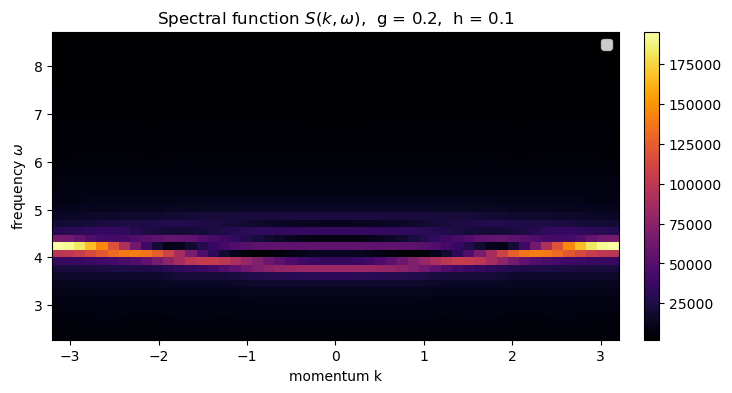

In [ ]:
Corr_new = np.array(Corr_new)
Swk_new, momenta_new, freqs_new = FT.get_Swk(Corr_new, L = 60, dt = 0.001)
FT.plot_Swk(Swk_new, momenta_new, freqs_new, title = r'Spectral function $S(k, \omega)$,  g = 0.2,  h = 0.1', offset=15, interval=40)

PUNTO PRINCIPALE del colloquium: capire la fisica di quello che si sta vedendo!